# Import ibt files

In [24]:
import pandas as pd
import irsdk
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
path_root = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
ibt_file = path_root + "data/mx5 mx52016_charlotte 2025 roval2025 01-2026-zigzage.ibt"

# --- Configuration ---
IBT_FILES = [
    Path(ibt_file)
]

USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = ['SessionTime','Lap','Speed','RPM',
                    'LapDistPct','SteeringWheelAngle',
                    'LatAccel','LongAccel','Lat','Lon']
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)

df_coords = load_from_ibt(Path(ibt_file))

In [28]:
df_coords['Lap'].value_counts()

Lap
2    11217
1     8038
0     6374
3     6167
4      491
Name: count, dtype: int64

In [38]:
# --- 2. FUNÇÃO PARA FORMATAR MM:SS:ms ---
def format_lap_time(seconds):
    if seconds <= 0:
        return "00:00:000"
    minutes = int(seconds // 60)
    remainder_seconds = seconds % 60
    # {:02d} força 2 dígitos para minutos
    # {:06.3f} força 2 dígitos para segundos + ponto + 3 para milissegundos
    return f"{minutes:02d}:{remainder_seconds:06.3f}".replace('.', ':')

# --- 3. CÁLCULO DOS TEMPOS POR VOLTA ---
# Calculamos o tempo final menos o tempo inicial de cada Lap
lap_summary = df_coords.groupby('Lap')['SessionTime'].agg(['min', 'max'])
lap_summary['Duration_s'] = lap_summary['max'] - lap_summary['min']

# Aplicamos a formatação
lap_summary['Time_Formatted'] = lap_summary['Duration_s'].apply(format_lap_time)

# --- 4. EXIBIÇÃO ---
print("=== Resumo de Voltas ===")
# Removemos a volta 0 se ela for apenas a saída dos boxes (opcional)
lap_summary_filtered = lap_summary[lap_summary.index > 0]

print(lap_summary[['Time_Formatted']])

=== Resumo de Voltas ===
    Time_Formatted
Lap               
0        08:56:683
1        02:13:950
2        03:07:000
3        01:42:767
4        00:08:183


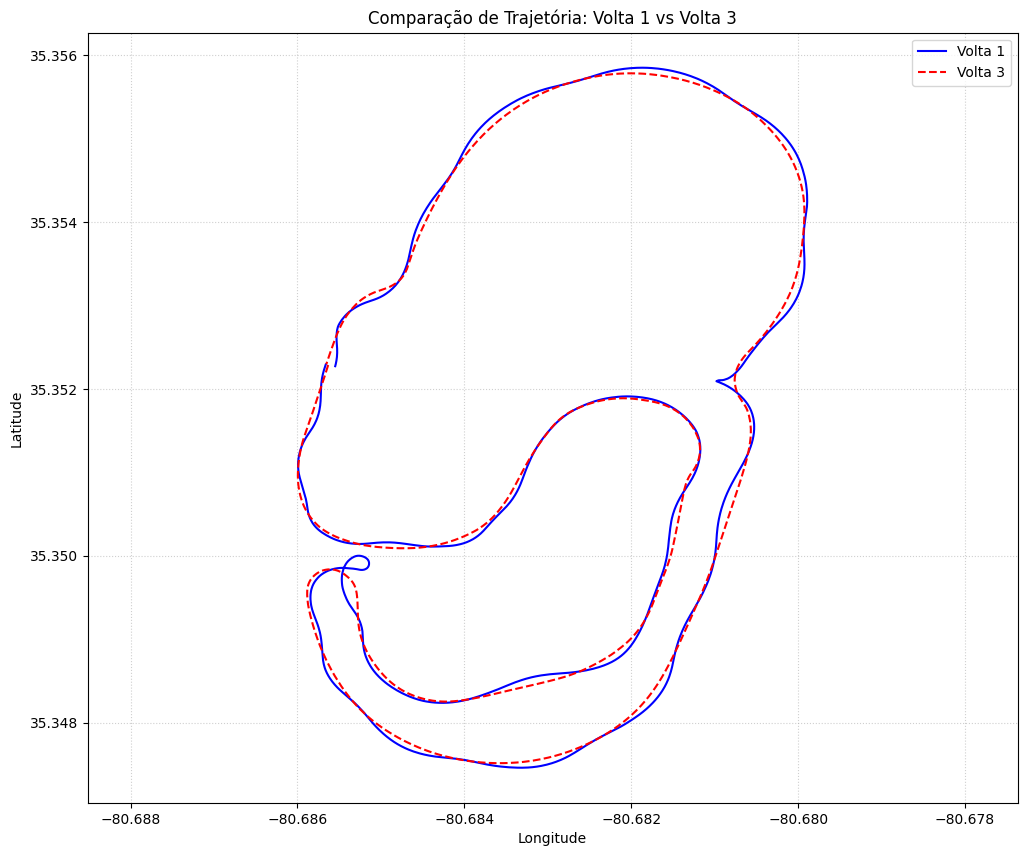

In [44]:
def plot_lap_comparison(df_input, lap_a, lap_b):
    # 1. Filtrar os dados para as duas voltas escolhidas
    data_a = df_input[df_input['Lap'] == lap_a]
    data_b = df_input[df_input['Lap'] == lap_b]

    # 2. Criar a figura
    plt.figure(figsize=(12, 10))

    # Plotar a primeira volta (ex: em Azul)
    plt.plot(data_a['Lon'], data_a['Lat'], color='blue', linewidth=1.5, label=f'Volta {lap_a}')
    
    # Plotar a segunda volta (ex: em Vermelho pontilhado para destacar diferenças)
    plt.plot(data_b['Lon'], data_b['Lat'], color='red', linewidth=1.5, linestyle='--', label=f'Volta {lap_b}')

    # 3. Ajustes de visualização do mapa
    plt.axis('equal') # Mantém a proporção real da pista
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Comparação de Trajetória: Volta {lap_a} vs Volta {lap_b}')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    # Zoom opcional: Se quiser ver uma curva específica, você pode limitar o gráfico aqui
    # plt.xlim(lon_min, lon_max) 
    
    plt.show()

# --- Exemplo de uso ---
# Supondo que você queira comparar a volta 2 com a volta 5:
plot_lap_comparison(df_coords, lap_a=1, lap_b=3)

# Testando com o OpenStreetMap



In [47]:
%pip install osmnx


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 10.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ------ --------------------------------- 3.7/22.9 MB 17.4 MB/s eta 0:00:02
   ------------ --------------------------- 7.3/22.9 MB 17.1 MB/s eta 0:00:01
   ------------------ --------------------- 10.7/22.9 MB 17.1 MB/s eta 0:00:01
   -------------------------- ------------- 14.9/22.9 MB 17.8 MB/s eta 0:00:01
   --------------------------------- ------ 19.1/22.9 MB 18.3 MB/s eta 0:00:01
   ---------------------------------------  22.5/22.9 MB 17.8 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 15.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------------------ --------------------- 2.9/6.3 MB 15.1 MB/s eta 0:00:01
   -------------------------------------- - 6.0/6.3 MB 14.5 MB/s eta 0:00:01
   -------

Buscando geometrias em Charlotte Motor Speedway...
Sucesso! Encontrados 3 polígonos.


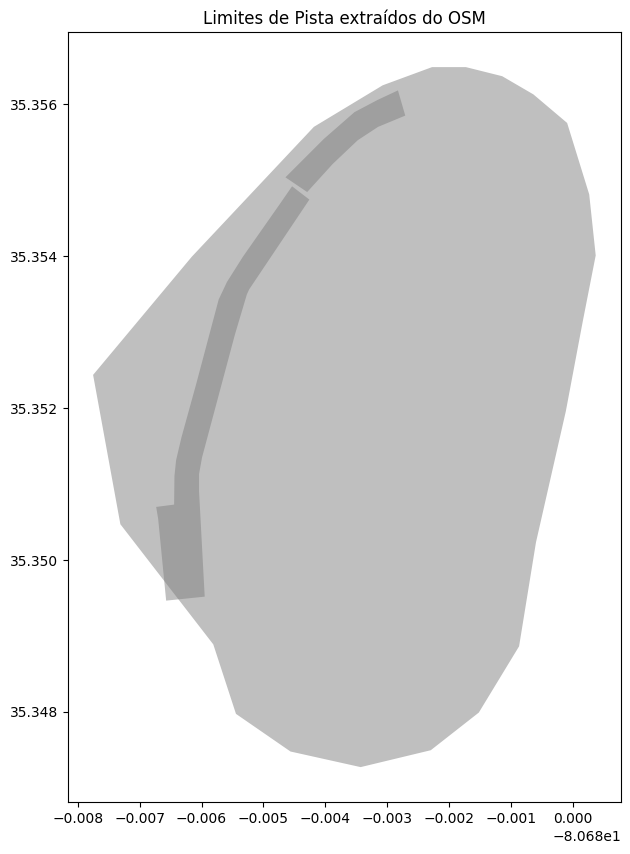

Index(['geometry', 'highway', 'name', 'oneway', 'sport', 'surface', 'building',
       'building:levels', 'lanes', 'lit', 'width', 'leisure'],
      dtype='object')


In [50]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Definir tags mais abrangentes para autódromos
# Charlotte Motor Speedway no OSM geralmente usa 'motorsport' ou 'motor_racing'
tags = {
    "leisure": ["motorsport", "track"],
    "sport": "motor",
    "highway": "race_track"
}

print("Buscando geometrias em Charlotte Motor Speedway...")

try:
    # Tentamos buscar pelo nome e pelas tags ampliadas
    track_geometries = ox.features_from_place("Charlotte Motor Speedway", tags=tags)
    
    if track_geometries.empty:
        print("Nenhum recurso encontrado com essas tags. Tentando busca por proximidade...")
        # Alternativa: Buscar em um raio de 2km a partir das coordenadas centrais conhecidas
        # Charlotte está aprox em: 35.3515, -80.6827
        track_geometries = ox.features_from_point((35.3515, -80.6827), tags=tags, dist=2000)

    # 2. Filtrar polígonos (as bordas da pista)
    track_polygons = track_geometries[track_geometries.geometry.type.isin(['Polygon', 'MultiPolygon'])]

    if not track_polygons.empty:
        print(f"Sucesso! Encontrados {len(track_polygons)} polígonos.")
        
        # Plotar para conferir
        fig, ax = plt.subplots(figsize=(10, 10))
        track_polygons.plot(ax=ax, facecolor='gray', alpha=0.5)
        plt.title("Limites de Pista extraídos do OSM")
        plt.show()
        
        # Mostrar as colunas para você ver como os dados estão organizados
        print(track_polygons.columns)
    else:
        print("Geometrias encontradas, mas nenhuma é do tipo Polígono.")

except Exception as e:
    print(f"Erro na busca: {e}")